In [1]:
import matplotlib
import os
import logging
from marss2l.utils import setup_stream_logger, fs_from_path, pathjoin

logger = logging.getLogger(__name__)
setup_stream_logger(logger, level=logging.DEBUG)

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

/home/gonzalo/mambaforge/envs/marss2ltacopy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from marss2l import loaders

from marss2l.huggingface import CSV_PATH_DEFAULT_HF, CSV_PLUME_PATH_DEFAULT_HF

# path_images = "../data/validated_images_all.csv"
# path_prepend_data = "../data/"

# Load images and plumes from HuggingFace
path_images = CSV_PATH_DEFAULT_HF

fs = fs_from_path(path_images)

dataframe_data_traintest = loaders.read_csv(path_images, 
                                            add_columns_for_analysis=False, 
                                            fs=fs)
dataframe_data_traintest.shape

(93538, 52)

In [7]:
from marss2l.loaders import DatasetPlumes
from marss2l import dataframe_image_plumes
import json
import os


split = "test_2023"
mode = "test"

dataframe_image_test, _, _ = dataframe_image_plumes.load_dataframe_split(
        dataframe_or_csv_path=dataframe_data_traintest,
        dataframe_or_csv_path_plumes=None,
        dataframe_or_csv_path_sources=None,
        split=split,
        fs=fs,
        logger=logger,
        all_locs=None,
        load_plumes=False
    )
# split = "train_2023"
# mode = "train"

dataset = DatasetPlumes(mode=mode,
                        strprependlogs=split,
                        device="cpu",
                        image_dataframe=dataframe_image_test,
                        do_simulation=False,
                        analysis_mode=True,
                        fs=fs)
dataset.image_dataframe

,s2path,plumepath,cloudmaskpath,ch4path,wind_u,wind_v,vza,sza,percentage_clear,tile,...,wind_source,id_loc_image,geotransform,plumes_good_overlap,year,year_month,year_month_day,wind_speed,isplumeneg,int_index
0,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,0.410492,-1.204330,2.680000,56.700001,100.000000,LC09_L1TP_185040_20241230_20241230_02_T1,...,ECMWF/ERA5_LAND/HOURLY,6c766e53-1c19-450a-93d8-4a136721b930,"(10.0, 0.0, 729855.0, 0.0, -10.0, 3205635.0, 0...",True,2024,2024-12,2024-12-30,1.272366,True,0
1,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,9.142639,-2.482208,7.114630,55.111009,99.948534,S2B_MSIL1C_20241226T093319_N0511_R136_T33RYN_2...,...,ECMWF/ERA5_LAND/HOURLY,b2fdc3f5-4476-4902-a4d1-58523e54dada,"(10.0, 0.0, 729850.0, 0.0, -10.0, 3205650.0, 0...",True,2024,2024-12,2024-12-26,9.473606,True,1
2,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,1.702469,-2.103516,7.110202,55.033870,99.963239,S2A_MSIL1C_20241221T093421_N0511_R136_T33RYN_2...,...,ECMWF/ERA5_LAND/HOURLY,7b31ece7-ad31-4ff4-85cd-b156babad647,"(10.0, 0.0, 729850.0, 0.0, -10.0, 3205650.0, 0...",True,2024,2024-12,2024-12-21,2.706137,True,2
3,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,-0.854843,-2.715822,2.830000,35.939999,100.000000,LC09_L1TP_185040_20240925_20240925_02_T1,...,ECMWF/ERA5_LAND/HOURLY,1f01fdd9-0240-4999-a389-3a4b1e0a1186,"(10.0, 0.0, 729855.0, 0.0, -10.0, 3205635.0, 0...",True,2024,2024-09,2024-09-25,2.847182,True,3
4,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,-1.500580,2.065903,2.680000,31.709999,100.000000,LC09_L1TP_185040_20240909_20240909_02_T1,...,ECMWF/ERA5_LAND/HOURLY,8fab1041-ca3b-454c-8a1d-5870723814e6,"(10.0, 0.0, 729855.0, 0.0, -10.0, 3205635.0, 0...",True,2024,2024-09,2024-09-09,2.553369,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43519,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,1.213076,0.177032,0.990000,56.970000,100.000000,LC09_L1TP_031038_20240122_20240122_02_T1,...,ECMWF/ERA5_LAND/HOURLY,3085fdec-0f36-4f31-89af-77b5d3861ca3,"(10.0, 0.0, 646235.0, 0.0, -10.0, 3572175.0, 0...",True,2024,2024-01,2024-01-22,1.225925,True,43519
43520,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,3.376892,0.742538,3.001441,56.950558,100.000000,S2A_MSIL1C_20240110T173711_N0510_R055_T13SFR_2...,...,ECMWF/ERA5_LAND/HOURLY,d59dc36c-5e35-4eee-a57b-cfaa89eec880,"(10.0, 0.0, 646250.0, 0.0, -10.0, 3572170.0, 0...",True,2024,2024-01,2024-01-10,3.457566,True,43520
43521,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,4.018646,-1.704391,0.960000,59.010000,100.000000,LC09_L1TP_031038_20240106_20240106_02_T1,...,ECMWF/ERA5_LAND/HOURLY,b7673bc3-581d-47cc-9c60-294642a40520,"(10.0, 0.0, 646235.0, 0.0, -10.0, 3572175.0, 0...",True,2024,2024-01,2024-01-06,4.365142,True,43521
43522,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,https://huggingface.co/datasets/UNEP-IMEO/MARS...,None,5.205490,-0.843931,3.003937,57.405290,100.000000,S2B_MSIL1C_20240105T173729_N0510_R055_T13SFR_2...,...,ECMWF/ERA5_LAND/HOURLY,65afddf0-51bd-4da8-994c-35b687c47bbc,"(10.0, 0.0, 646250.0, 0.0, -10.0, 3572170.0, 0...",True,2024,2024-01,2024-01-05,5.273457,True,43522


## Plot plumes in the test dataset

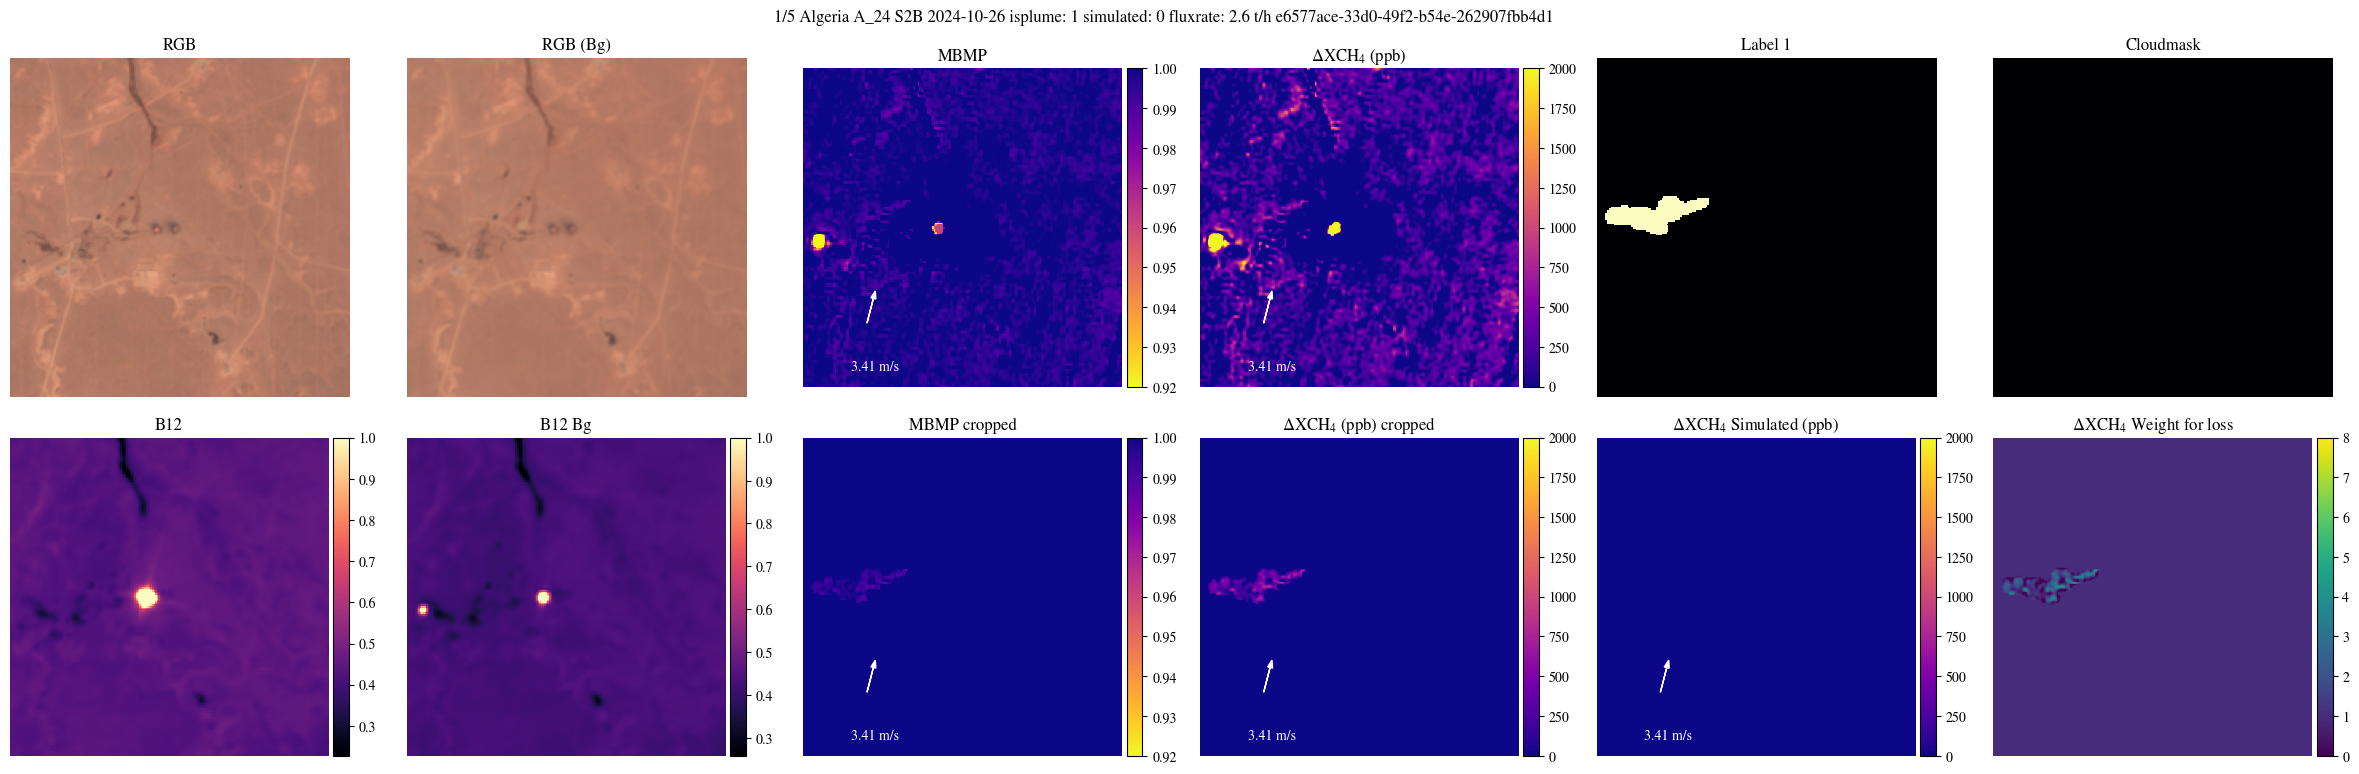

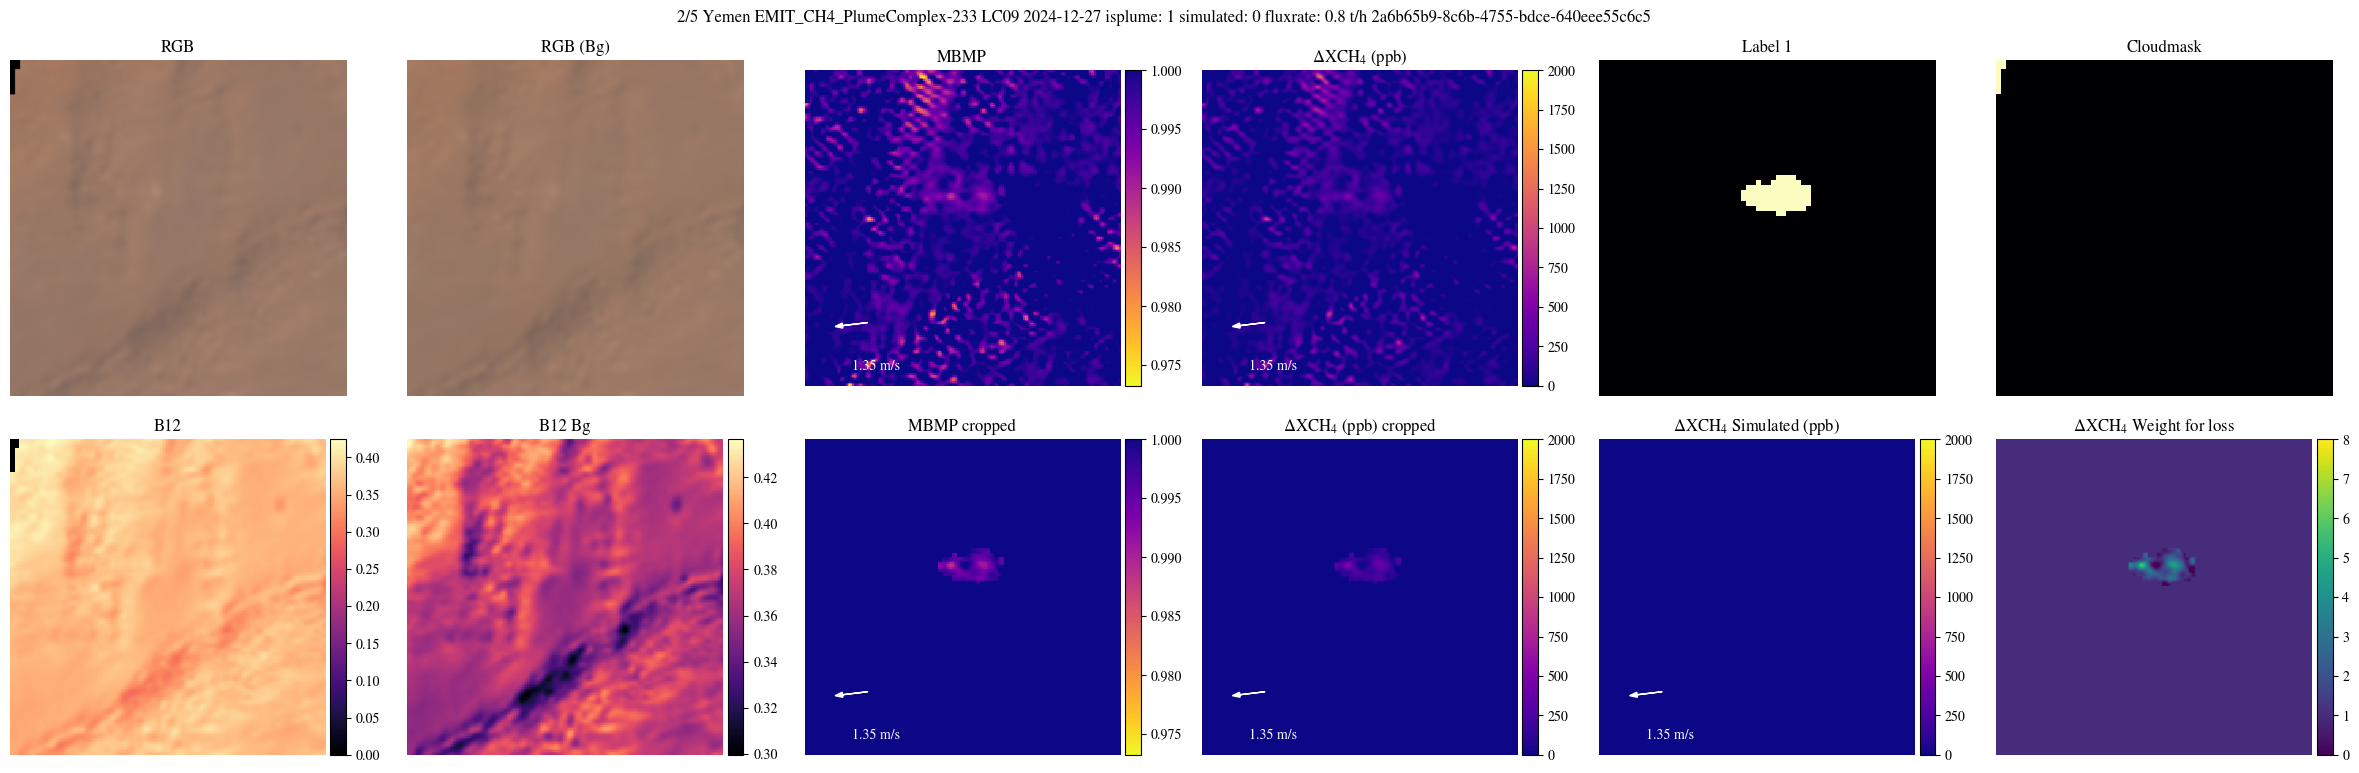

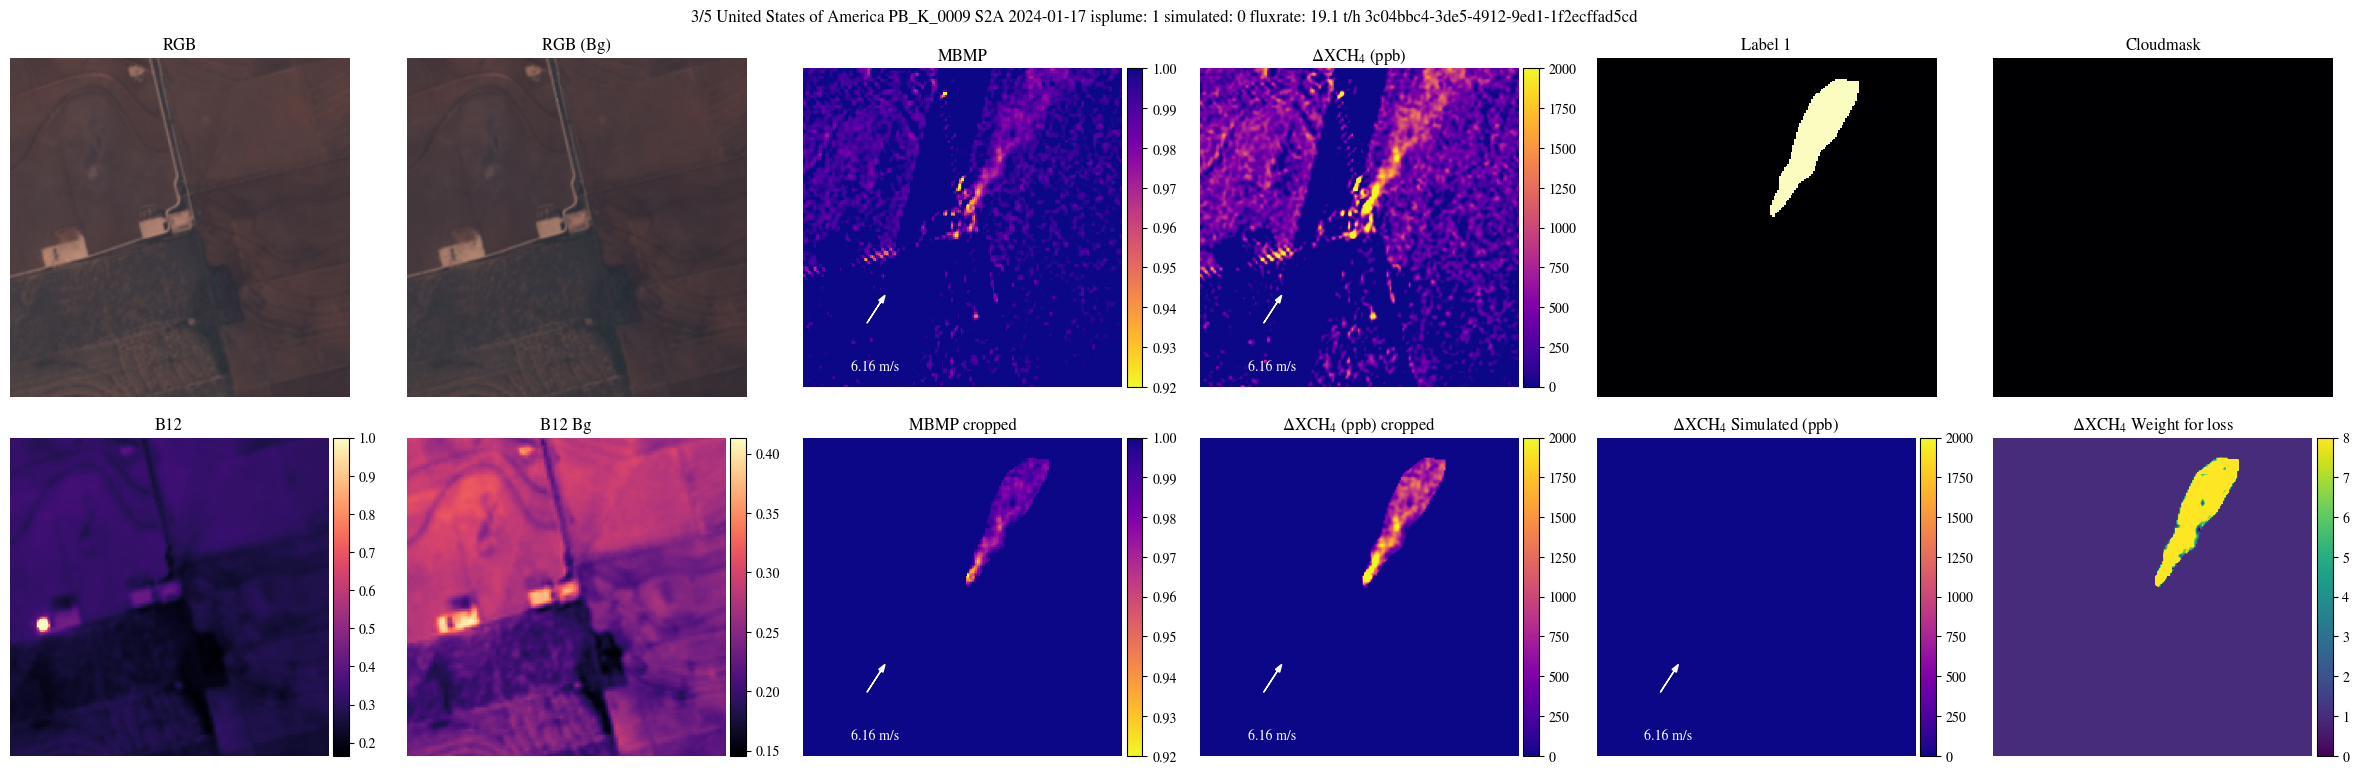

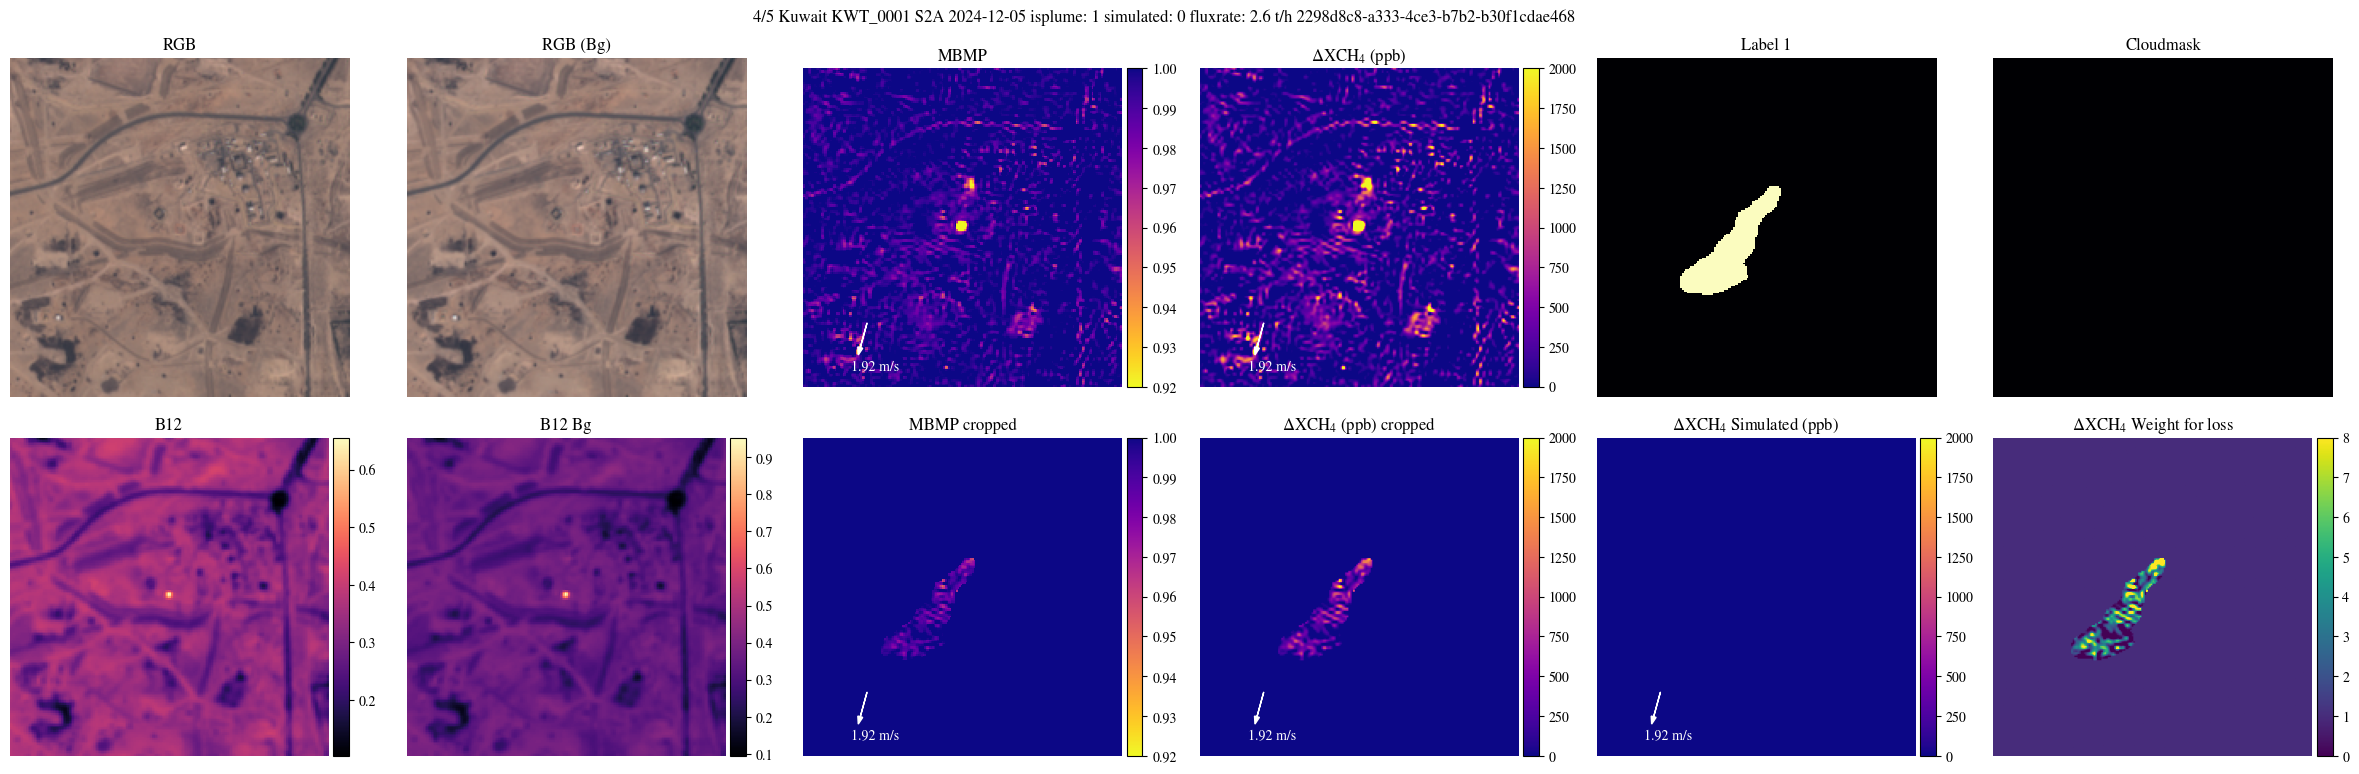

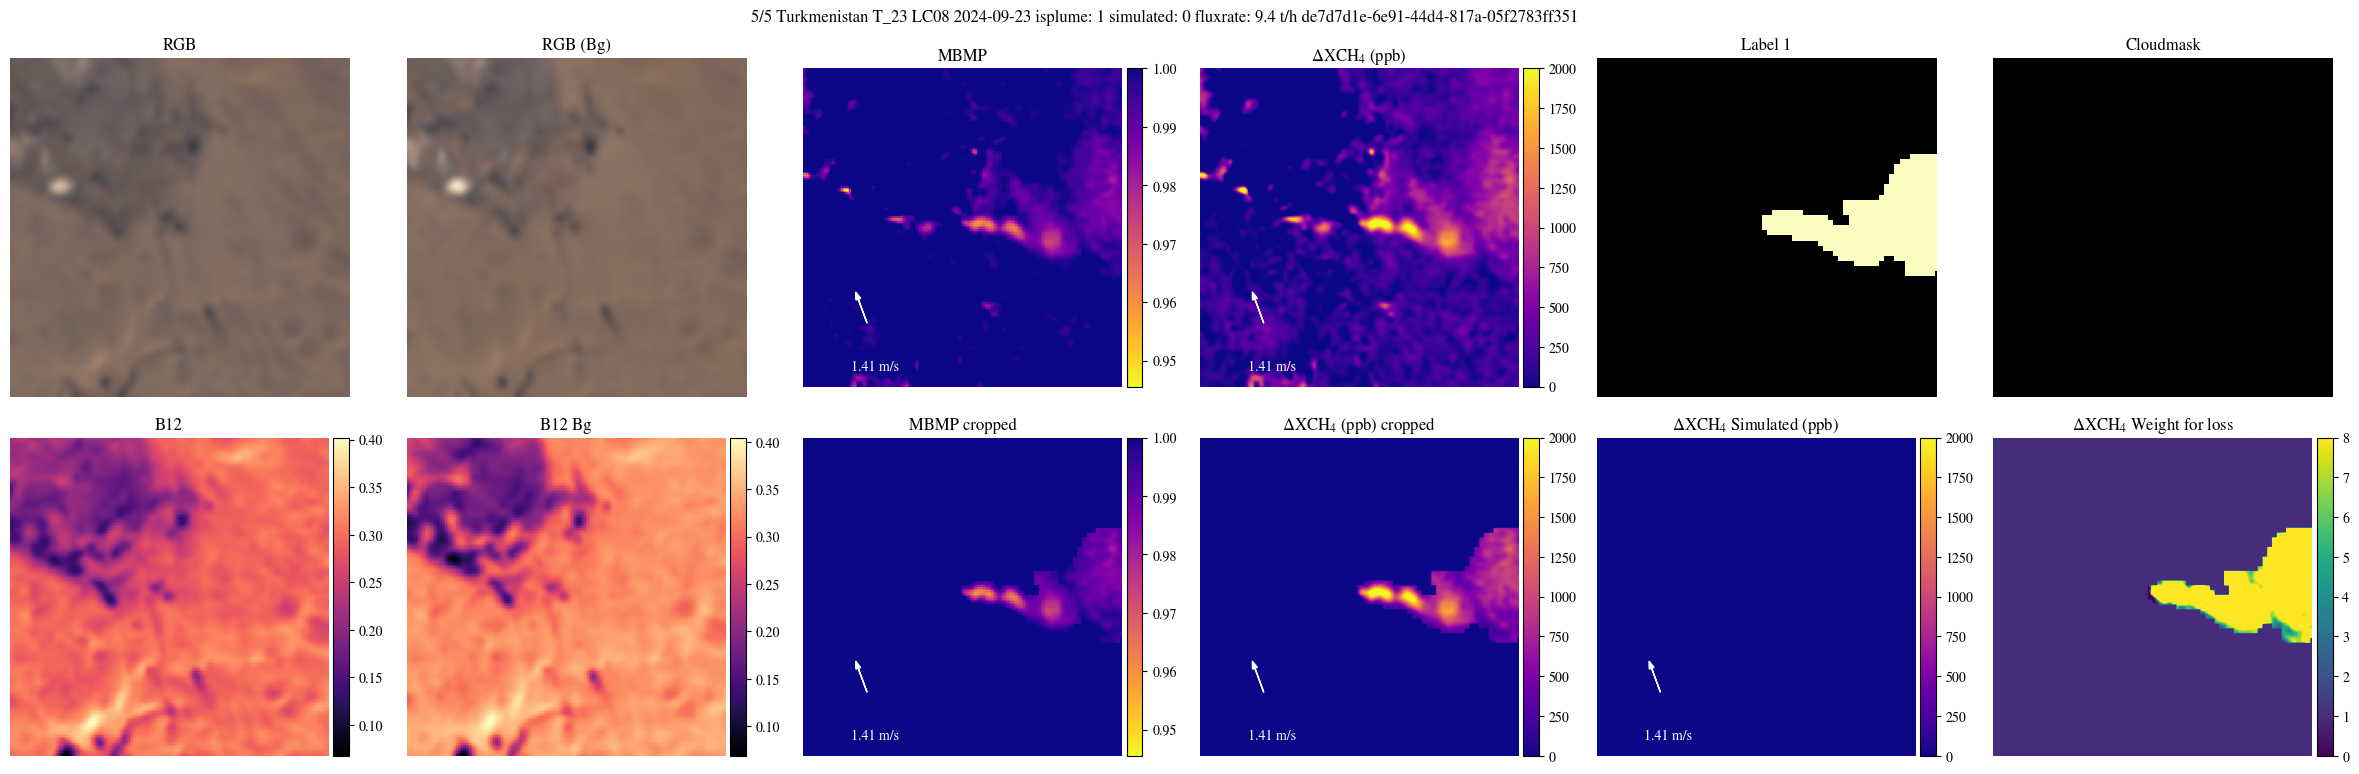

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from marss2l.loss import DEFAULT_POS_WEIGHT

size = 5
idx_to_plot = np.random.choice(dataset.image_dataframe[dataset.image_dataframe.isplume].index,replace=False, size=size)
for _i, idx in enumerate(idx_to_plot):
    fig, axs = dataset.plot_item(dataset[idx], text_prepend=f"{_i+1}/{len(idx_to_plot)}", pos_weight=DEFAULT_POS_WEIGHT)
    plt.show(fig)
    plt.close(fig)  